## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"До очистки: train={train.shape}, test={test.shape}")

train = train[(train['RiskScore'] > -1000) & (train['RiskScore'] < 1000)]
print(f"После очистки: train={train.shape}")

for col in train.columns:
    if col == 'RiskScore':
        continue
    if col in test.columns:
        if train[col].dtype in ['int64', 'float64']:
            fill_value = train[col].median()
            train[col].fillna(fill_value, inplace=True)
            test[col].fillna(fill_value, inplace=True)
        else:
            if len(train[col].mode()) > 0:
                fill_value = train[col].mode()[0]
                train[col].fillna(fill_value, inplace=True)
                test[col].fillna(fill_value, inplace=True)

print(f"Пропуски: train={train.isnull().sum().sum()}, test={test.isnull().sum().sum()}")


До очистки: train=(11017, 35), test=(5000, 35)
После очистки: train=(10272, 35)
Пропуски: train=0, test=0


## EDA

In [ ]:
df = pd.read_csv('train.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (11017, 35)

Первые 5 строк:


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

In [ ]:
print("Статистика пропущенных значений:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_percent
}).sort_values('Процент', ascending=False)
print(missing_df[missing_df['Пропущено'] > 0])

Статистика пропущенных значений:
                            Пропущено   Процент
TotalAssets                      1031  9.358265
CreditScore                      1031  9.358265
LoanAmount                       1031  9.358265
BaseInterestRate                 1031  9.358265
NetWorth                         1031  9.358265
MonthlyDebtPayments              1031  9.358265
CheckingAccountBalance           1031  9.358265
LoanPurpose                      1031  9.358265
BankruptcyHistory                1031  9.358265
JobTenure                         530  4.810747
TotalLiabilities                  530  4.810747
MonthlyIncome                     530  4.810747
UtilityBillsPaymentHistory        530  4.810747
ApplicationDate                   530  4.810747
EmploymentStatus                  530  4.810747
EducationLevel                    530  4.810747
InterestRate                      530  4.810747
MonthlyLoanPayment                530  4.810747
TotalDebtToIncomeRatio            530  4.810747
Experie

In [ ]:
print("Статистическое описание числовых признаков:")
df.describe().T

Статистическое описание числовых признаков:


,count,mean,std,min,25%,50%,75%,max
Age,10487.0,39.850386,1.161413e+01,1.800000e+01,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,10487.0,131587.872127,1.157919e+05,1.500000e+04,20959.500000,89015.000000,257025.000000,7.485080e+05
CreditScore,9986.0,678.082716,1.751925e+02,3.000000e+02,550.000000,722.500000,850.000000,8.500000e+02
LoanAmount,9986.0,29874.218306,2.770551e+04,1.063000e+03,12658.000000,21828.500000,37158.000000,4.189970e+05
LoanDuration,10487.0,53.439878,2.449356e+01,1.200000e+01,36.000000,48.000000,60.000000,1.200000e+02
NumberOfDependents,10487.0,1.568323,1.418684e+00,0.000000e+00,0.000000,1.000000,3.000000,6.000000e+00
MonthlyDebtPayments,9986.0,546.458642,5.019819e+02,1.300000e+01,233.250000,398.000000,685.000000,1.087900e+04
CreditCardUtilizationRate,10487.0,0.284397,1.592405e-01,3.673558e-03,0.158929,0.262229,0.391683,9.146347e-01
NumberOfOpenCreditLines,10487.0,3.033565,1.740186e+00,0.000000e+00,2.000000,3.000000,4.000000,1.200000e+01
NumberOfCreditInquiries,10487.0,0.979498,9.909274e-01,0.000000e+00,0.000000,1.000000,2.000000,6.000000e+00


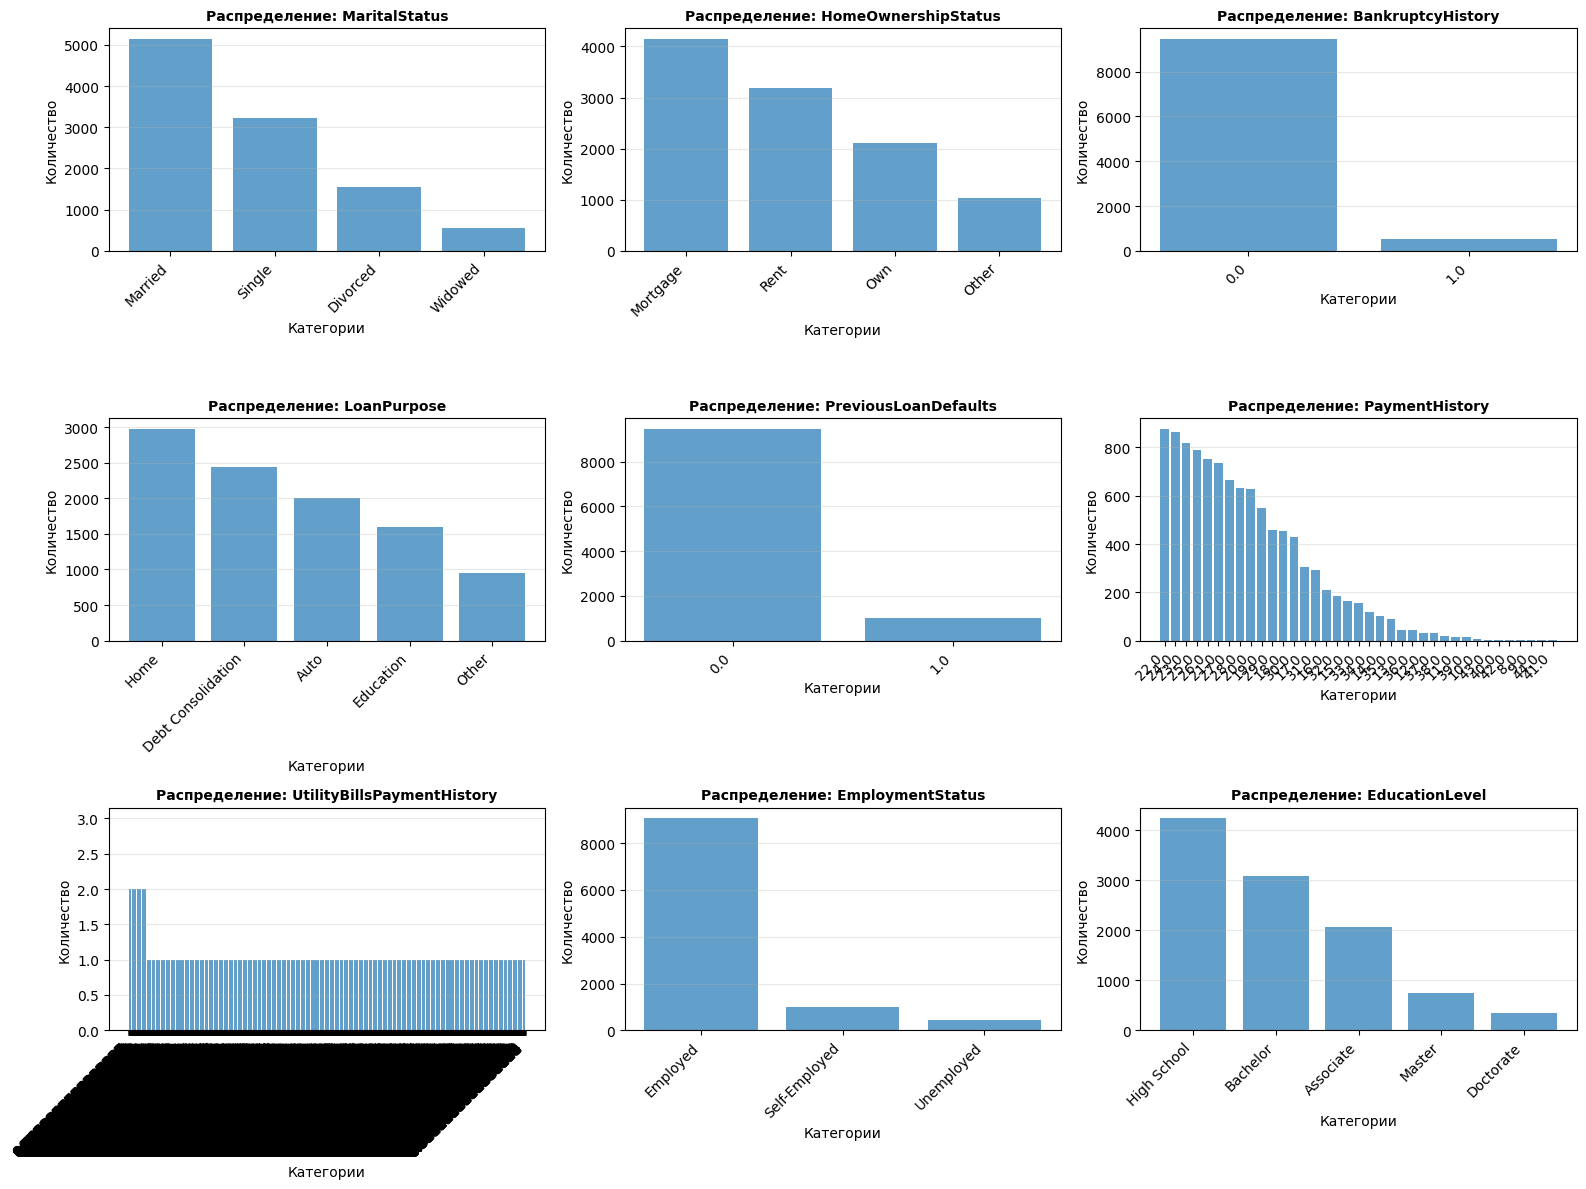


Уникальные значения категориальных признаков:

MaritalStatus: 4 уникальных значений
MaritalStatus
Married     5145
Single      3217
Divorced    1562
Widowed      563
Name: count, dtype: int64

HomeOwnershipStatus: 4 уникальных значений
HomeOwnershipStatus
Mortgage    4148
Rent        3186
Own         2116
Other       1037
Name: count, dtype: int64

BankruptcyHistory: 2 уникальных значений
BankruptcyHistory
0.0    9461
1.0     525
Name: count, dtype: int64

LoanPurpose: 5 уникальных значений
LoanPurpose
Home                  2981
Debt Consolidation    2446
Auto                  2010
Education             1601
Other                  948
Name: count, dtype: int64

PreviousLoanDefaults: 2 уникальных значений
PreviousLoanDefaults
0.0    9476
1.0    1011
Name: count, dtype: int64

PaymentHistory: 37 уникальных значений
PaymentHistory
22.0    878
24.0    866
23.0    820
25.0    788
26.0    752
21.0    735
27.0    667
28.0    631
20.0    628
19.0    550
29.0    459
18.0    454
30.0    429
17.

In [ ]:
categorical_cols = ['MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 
                    'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 
                    'UtilityBillsPaymentHistory', 'EmploymentStatus', 'EducationLevel']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, alpha=0.7)
    axes[idx].set_title(f'Распределение: {col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Категории')
    axes[idx].set_ylabel('Количество')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nУникальные значения категориальных признаков:")
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} уникальных значений")
    print(df[col].value_counts())


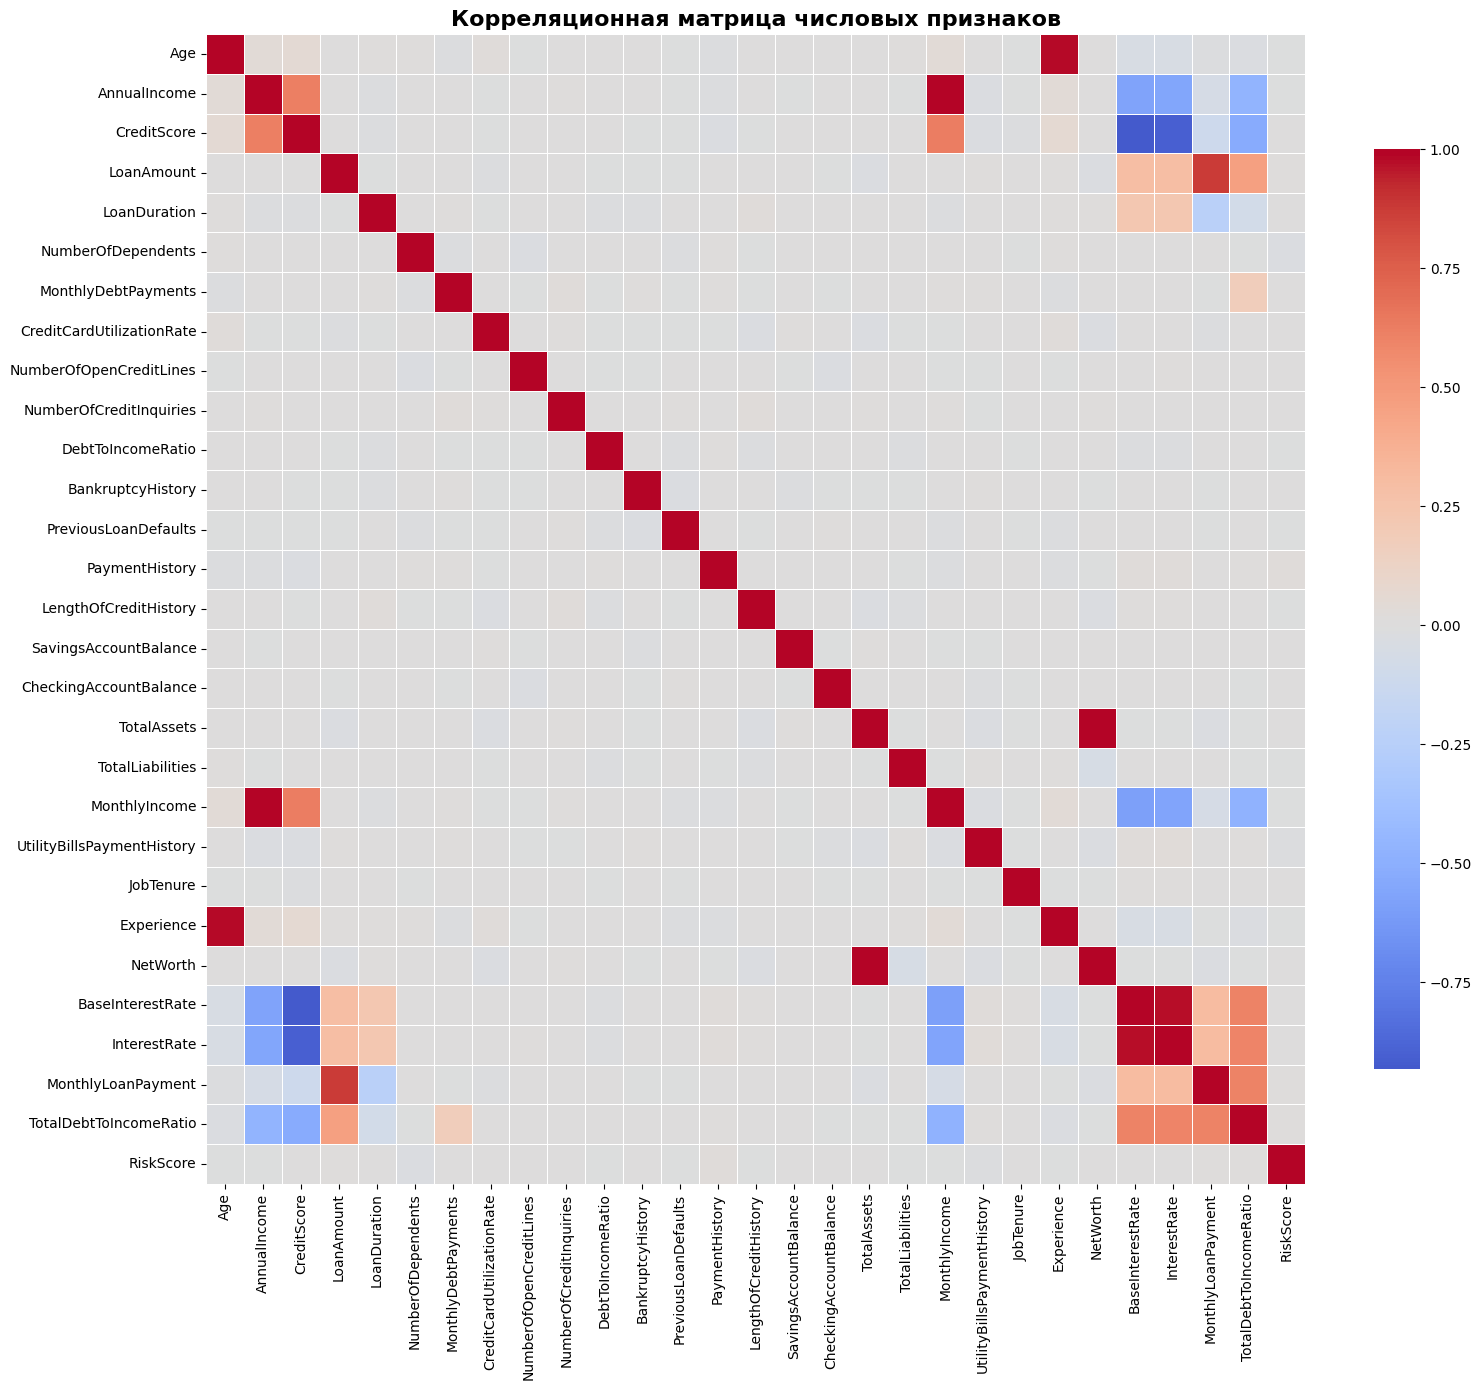


Топ-10 признаков с наибольшей корреляцией с RiskScore:
NumberOfDependents            0.023314
PaymentHistory                0.019144
TotalDebtToIncomeRatio        0.013879
UtilityBillsPaymentHistory    0.013865
MonthlyLoanPayment            0.012366
LoanAmount                    0.011771
NumberOfCreditInquiries       0.011055
LengthOfCreditHistory         0.009448
NetWorth                      0.008804
AnnualIncome                  0.008460
Name: RiskScore, dtype: float64


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(16, 14))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица числовых признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nТоп-10 признаков с наибольшей корреляцией с RiskScore:")
risk_corr = correlation_matrix['RiskScore'].abs().sort_values(ascending=False)
print(risk_corr[1:11])

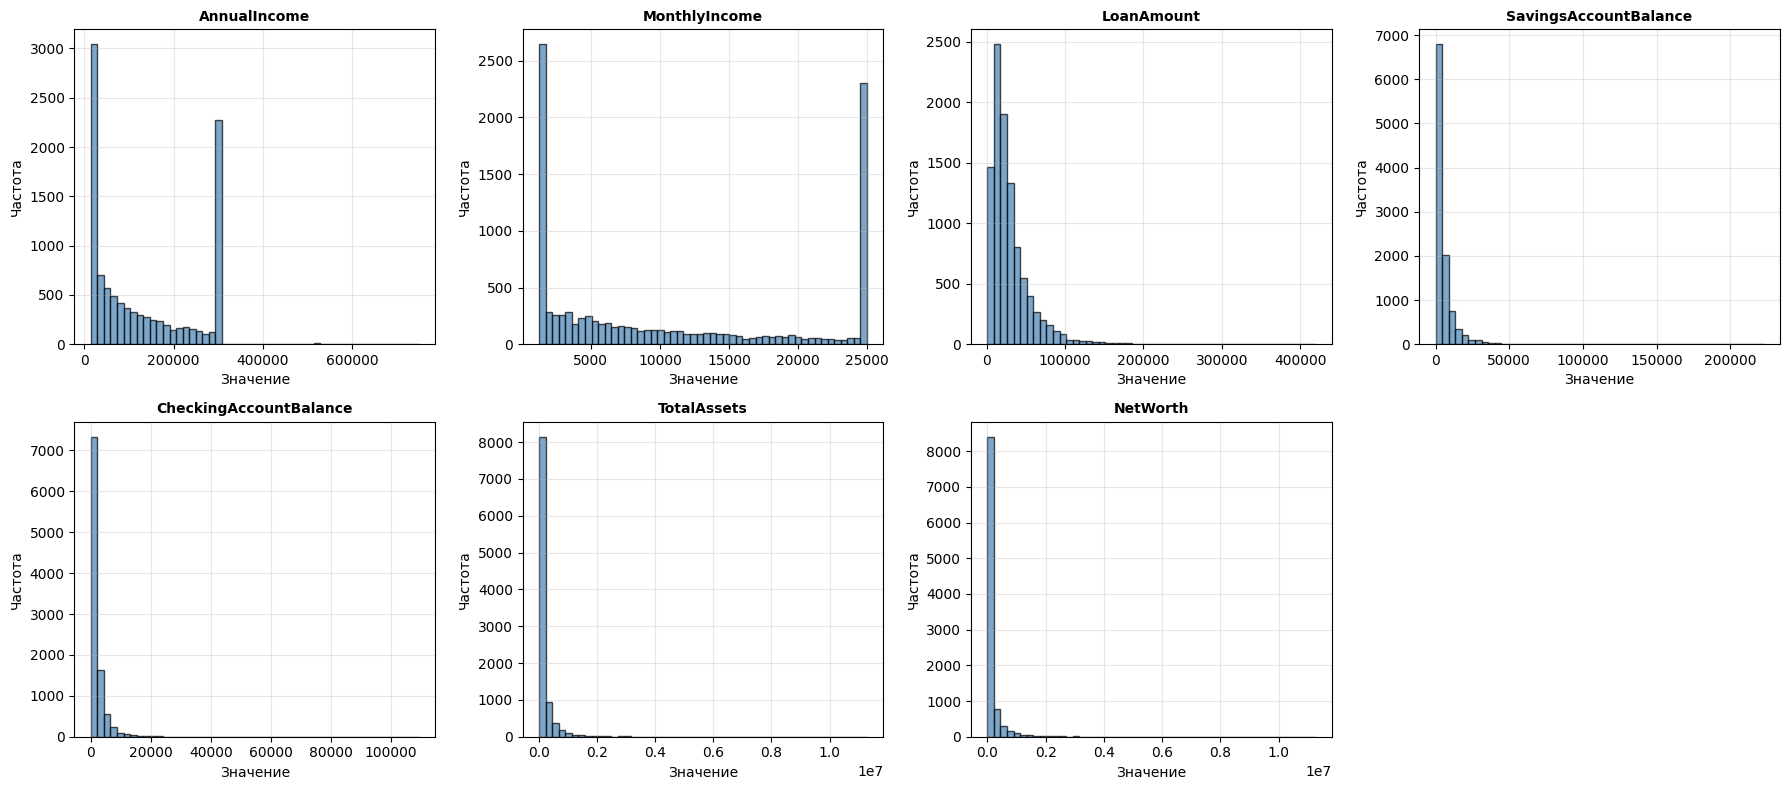

In [ ]:
financial_features = ['AnnualIncome', 'MonthlyIncome', 'LoanAmount', 
                      'SavingsAccountBalance', 'CheckingAccountBalance', 
                      'TotalAssets', 'NetWorth']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(financial_features):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(alpha=0.3)

axes[7].axis('off') 

plt.tight_layout()
plt.show()

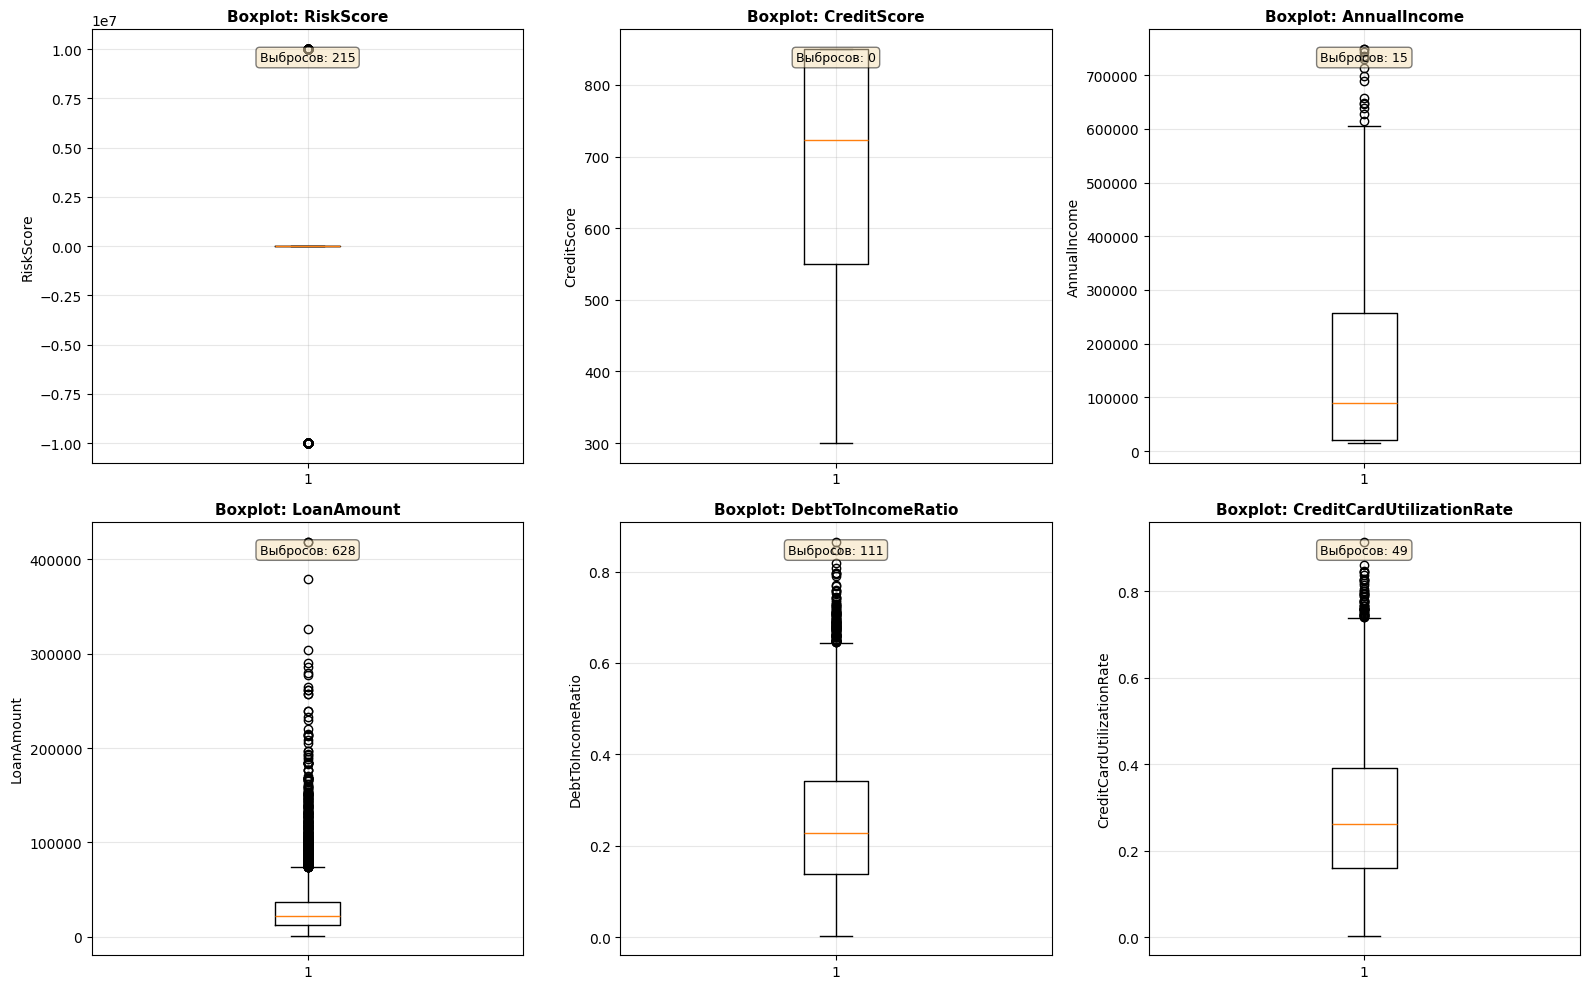

In [ ]:
key_features = ['RiskScore', 'CreditScore', 'AnnualIncome', 'LoanAmount', 
                'DebtToIncomeRatio', 'CreditCardUtilizationRate']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].count()
    axes[idx].text(0.5, 0.95, f'Выбросов: {outliers}', 
                   transform=axes[idx].transAxes, 
                   ha='center', va='top', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [3]:
print(train['RiskScore'].describe())

count    10272.000000
mean        48.358094
std         17.241456
min         14.841417
25%         32.722756
50%         44.195792
75%         65.124190
max         97.597249
Name: RiskScore, dtype: float64


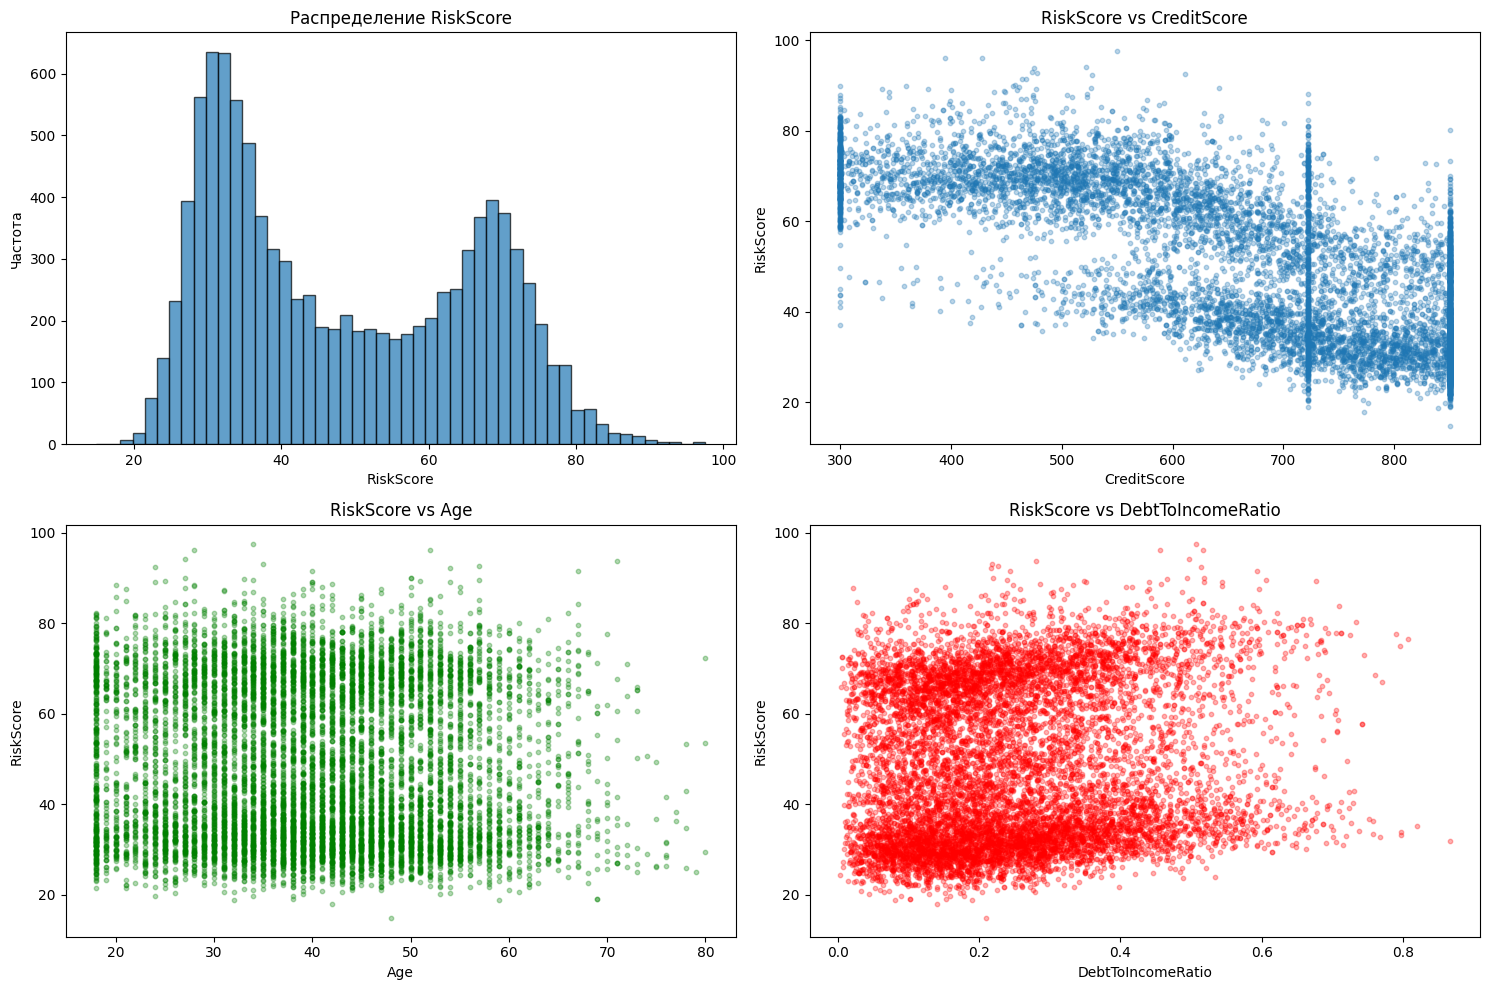

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(train['RiskScore'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение RiskScore')
axes[0, 0].set_xlabel('RiskScore')
axes[0, 0].set_ylabel('Частота')

axes[0, 1].scatter(train['CreditScore'], train['RiskScore'], alpha=0.3, s=10)
axes[0, 1].set_title('RiskScore vs CreditScore')
axes[0, 1].set_xlabel('CreditScore')
axes[0, 1].set_ylabel('RiskScore')

axes[1, 0].scatter(train['Age'], train['RiskScore'], alpha=0.3, s=10, color='green')
axes[1, 0].set_title('RiskScore vs Age')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('RiskScore')

axes[1, 1].scatter(train['DebtToIncomeRatio'], train['RiskScore'], alpha=0.3, s=10, color='red')
axes[1, 1].set_title('RiskScore vs DebtToIncomeRatio')
axes[1, 1].set_xlabel('DebtToIncomeRatio')
axes[1, 1].set_ylabel('RiskScore')

plt.tight_layout()
plt.show()


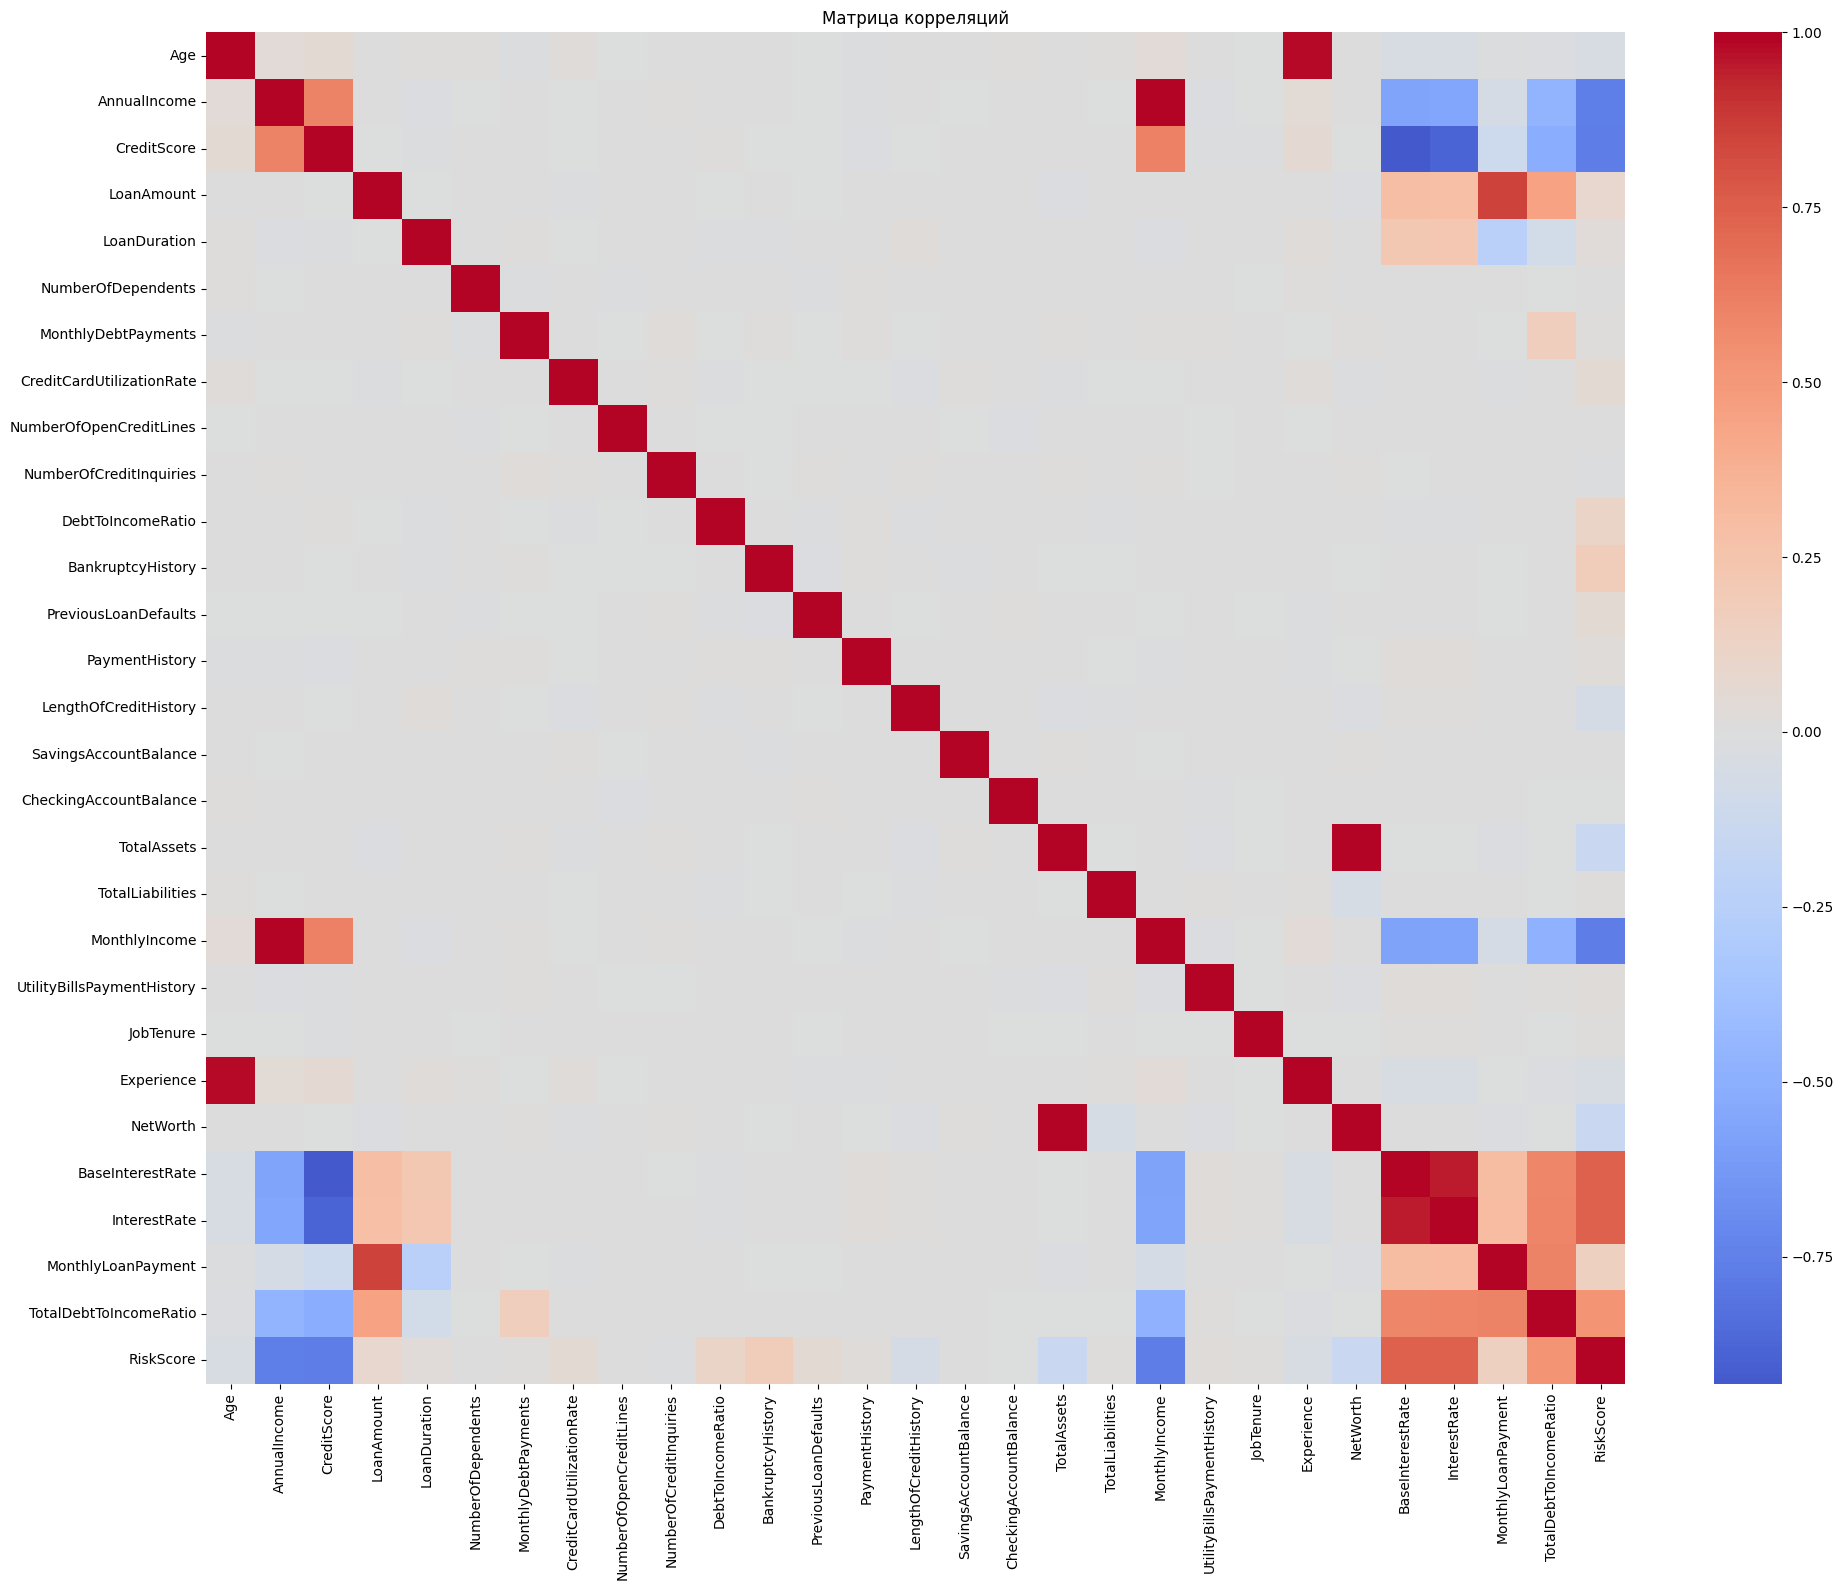

In [5]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = train[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

In [6]:
print("\nТоп-10 признаков по корреляции с RiskScore:")
risk_corr = correlation_matrix['RiskScore'].sort_values(ascending=False)
print(risk_corr.head(11))


Топ-10 признаков по корреляции с RiskScore:
RiskScore                    1.000000
InterestRate                 0.742634
BaseInterestRate             0.740451
TotalDebtToIncomeRatio       0.530729
BankruptcyHistory            0.173125
MonthlyLoanPayment           0.150830
DebtToIncomeRatio            0.110862
LoanAmount                   0.082715
CreditCardUtilizationRate    0.056063
PreviousLoanDefaults         0.054959
LoanDuration                 0.028269
Name: RiskScore, dtype: float64


## Train

In [ ]:
class MinMaxNormalizer:
    def __init__(self):
        self.params = {}
    
    def fit(self, X):
        self.params['min'] = X.min()
        self.params['max'] = X.max()
        return self
    
    def transform(self, X):
        range_val = (self.params['max'] - self.params['min']).replace(0, 1)
        return (X - self.params['min']) / range_val
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [ ]:
sample_X = train.select_dtypes(include=[np.number]).drop('RiskScore', axis=1).iloc[:100]

norm_mm = MinMaxNormalizer()
X_mm = norm_mm.fit_transform(sample_X)
print(f"Min-max: min={X_mm.min().min():.6f}, max={X_mm.max().max():.2f}")


Min-max: min=0.000000, max=1.00


In [9]:
class MyLinearRegression:
    def __init__(self, method='analytic', learning_rate=0.01, n_iterations=1000, 
                 batch_size=32, random_state=42):
        self.method = method
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.history = []
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        
        if self.method == 'analytic':
            X_bias = np.c_[np.ones(n_samples), X]
            try:
                theta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
            except:
                theta = np.linalg.pinv(X_bias.T @ X_bias) @ X_bias.T @ y
            self.bias = theta[0]
            self.weights = theta[1:]
        
        elif self.method == 'gradient':
            self.weights = np.zeros(n_features)
            self.bias = 0
            for i in range(self.n_iterations):
                y_pred = X @ self.weights + self.bias
                dw = (1/n_samples) * (X.T @ (y_pred - y))
                db = (1/n_samples) * np.sum(y_pred - y)
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db
        
        elif self.method == 'sgd':
            # Стохастический градиентный спуск
            np.random.seed(self.random_state)
            self.weights = np.zeros(n_features)
            self.bias = 0
            for i in range(self.n_iterations):
                indices = np.random.permutation(n_samples)
                for start in range(0, n_samples, self.batch_size):
                    end = min(start + self.batch_size, n_samples)
                    X_batch = X[indices[start:end]]
                    y_batch = y[indices[start:end]]
                    y_pred = X_batch @ self.weights + self.bias
                    bs = len(X_batch)
                    dw = (1/bs) * (X_batch.T @ (y_pred - y_batch))
                    db = (1/bs) * np.sum(y_pred - y_batch)
                    self.weights -= self.learning_rate * dw
                    self.bias -= self.learning_rate * db
        return self
    
    def predict(self, X):
        return np.array(X) @ self.weights + self.bias

In [10]:
class MyRidgeRegression:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.weights = None
        self.bias = None
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        
        X_bias = np.c_[np.ones(n_samples), X]
        
        reg_matrix = np.eye(n_features + 1)
        reg_matrix[0, 0] = 0
        
        try:
            A = X_bias.T @ X_bias + self.alpha * reg_matrix
            theta = np.linalg.inv(A) @ X_bias.T @ y
        except np.linalg.LinAlgError:
            A = X_bias.T @ X_bias + self.alpha * reg_matrix
            theta = np.linalg.pinv(A) @ X_bias.T @ y
        
        self.bias = theta[0]
        self.weights = theta[1:]
        
        return self
    
    def predict(self, X):
        X = np.array(X)
        return X @ self.weights + self.bias
    
    @property
    def coef_(self):
        return self.weights
    
    @property
    def intercept_(self):
        return self.bias

In [50]:
sample_train = train.select_dtypes(include=[np.number]).dropna()
X_sample = sample_train.drop('RiskScore', axis=1).iloc[:1000]
y_sample = sample_train['RiskScore'].iloc[:1000]

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

normalizer = MinMaxNormalizer()
X_train_norm_s = normalizer.fit_transform(X_train_s)
X_val_norm_s = normalizer.transform(X_val_s)

print("Тестирование моделей на 1000 примерах:\n")

print("1. Аналитический метод:")
m1 = MyLinearRegression('analytic')
m1.fit(X_train_norm_s, y_train_s)
print(f"   MSE: {mean_squared_error(y_val_s, m1.predict(X_val_norm_s)):.4f}")

print("2. Градиентный спуск:")
m2 = MyLinearRegression('gradient', learning_rate=0.01, n_iterations=1000)
m2.fit(X_train_norm_s, y_train_s)
print(f"   MSE: {mean_squared_error(y_val_s, m2.predict(X_val_norm_s)):.4f}")

print("3. SGD:")
m3 = MyLinearRegression('sgd', learning_rate=0.01, n_iterations=500, batch_size=64)
m3.fit(X_train_norm_s, y_train_s)
print(f"   MSE: {mean_squared_error(y_val_s, m3.predict(X_val_norm_s)):.4f}")

print("4. Sklearn (для сравнения):")
m4 = LinearRegression()
m4.fit(X_train_norm_s, y_train_s)
print(f"   MSE: {mean_squared_error(y_val_s, m4.predict(X_val_norm_s)):.4f}")

print("5. MyRidge (alpha=1.0):")
m5 = MyRidgeRegression(alpha=1.0)
m5.fit(X_train_norm_s, y_train_s)
print(f"   MSE: {mean_squared_error(y_val_s, m5.predict(X_val_norm_s)):.4f}")


Тестирование моделей на 1000 примерах:

1. Аналитический метод:
   MSE: 56.5069
2. Градиентный спуск:
   MSE: 91.3725
3. SGD:
   MSE: 63.1456
4. Sklearn (для сравнения):
   MSE: 56.5069
5. MyRidge (alpha=1.0):
   MSE: 56.1054


In [12]:

def my_mse(y_true, y_pred):
    return np.mean((np.array(y_true) - np.array(y_pred)) ** 2)

def my_mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def my_r2(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def my_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [51]:
y_pred_test = m4.predict(X_val_norm_s)

print(f"MSE:  my={my_mse(y_val_s, y_pred_test):.4f}, sklearn={mean_squared_error(y_val_s, y_pred_test):.4f}")
print(f"MAE:  my={my_mae(y_val_s, y_pred_test):.4f}, sklearn={mean_absolute_error(y_val_s, y_pred_test):.4f}")
print(f"R²:   my={my_r2(y_val_s, y_pred_test):.4f}, sklearn={r2_score(y_val_s, y_pred_test):.4f}")
print(f"MAPE: my={my_mape(y_val_s, y_pred_test):.4f}%")


MSE:  my=56.5069, sklearn=56.5069
MAE:  my=6.0743, sklearn=6.0743
R²:   my=0.8092, sklearn=0.8092
MAPE: my=13.5247%


In [52]:
def k_fold_cv(X, y, model, k=5):
    X, y = np.array(X), np.array(y)
    n = len(X)
    fold_size = n // k
    indices = np.arange(n)
    np.random.shuffle(indices)
    scores = []
    
    for i in range(k):
        val_start = i * fold_size
        val_end = (i + 1) * fold_size if i < k - 1 else n
        val_idx = indices[val_start:val_end]
        train_idx = np.concatenate([indices[:val_start], indices[val_end:]])
        
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[val_idx])
        scores.append(my_mse(y[val_idx], y_pred))
        print(f"   Fold {i+1}: MSE={scores[-1]:.4f}")
    
    return np.mean(scores), np.std(scores)

def loo_cv(X, y, model, max_samples=200):
    X, y = np.array(X), np.array(y)
    n = min(len(X), max_samples)
    scores = []
    
    for i in range(n):
        X_train = np.concatenate([X[:i], X[i+1:n]])
        y_train = np.concatenate([y[:i], y[i+1:n]])
        model.fit(X_train, y_train)
        y_pred = model.predict(X[i:i+1])
        scores.append(my_mse(y[i:i+1], y_pred))
    
    return np.mean(scores), np.std(scores)

In [16]:
model_cv = MyLinearRegression('analytic')
mean_mse, std_mse = k_fold_cv(X_train_norm_s[:1000], y_train_s[:1000], model_cv, k=5)

   Fold 1: MSE=55.3986
   Fold 2: MSE=56.6743
   Fold 3: MSE=51.2489
   Fold 4: MSE=40.8962
   Fold 5: MSE=69.5008


In [20]:
model_loo = MyLinearRegression('analytic')
mean_mse_loo, std_mse_loo = loo_cv(X_train_norm_s[:200], y_train_s[:200], model_loo, max_samples=200)

In [ ]:
def extract_date_features(df, col='ApplicationDate'):
    if col not in df.columns:
        return df
    
    dates = pd.to_datetime(df[col], errors='coerce')
    mode_date = dates.mode()[0] if len(dates.mode()) > 0 else pd.Timestamp('2020-01-01')
    dates = dates.fillna(mode_date)
    
    df[f'{col}_Month'] = dates.dt.month
    df[f'{col}_Quarter'] = dates.dt.quarter
    df[f'{col}_DayOfYear'] = dates.dt.dayofyear
    df[f'{col}_DayOfWeek'] = dates.dt.dayofweek
    df[f'{col}_Week'] = dates.dt.isocalendar().week.astype(float)
    
    df[f'{col}_Month_Sin'] = np.sin(2 * np.pi * df[f'{col}_Month']/12)
    df[f'{col}_Month_Cos'] = np.cos(2 * np.pi * df[f'{col}_Month']/12)
    
    return df.drop(columns=[col])

In [22]:
def add_binning_features(df):
    """Разбивает непрерывные признаки на диапазоны (Bands)"""
    bins_config = {
        'CreditScore': [300, 580, 620, 660, 700, 740, 780, 820, 900],
        'AnnualIncome': [0, 40000, 60000, 80000, 100000, 150000, 200000, 300000, np.inf],
        'TotalDebtToIncomeRatio': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.65, 0.8, 1.0, np.inf],
        'InterestRate': [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, np.inf],
        'Age': [18, 30, 45, 60, np.inf],
        'LoanAmount': [0, 30000, 60000, 100000, np.inf],
        'MonthlyIncome': [0, 2000, 4000, 6000, 8000, 12000, 16000, 25000, np.inf],
        'CreditCardUtilizationRate': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.65, 0.8, np.inf]
    }
    
    for col, bins in bins_config.items():
        if col in df.columns:
            binned = pd.cut(df[col], bins=bins, labels=False, duplicates='drop')
            prefix = f"Bin_{col}"
            dummies = pd.get_dummies(binned, prefix=prefix, drop_first=True).astype(int)
            df = pd.concat([df, dummies], axis=1)
    
    return df

In [24]:
def preprocess_data(df, is_train=True, stats=None):
    EPS = 1e-5
    
    if 'EducationLevel' in df.columns:
        mapping = {'High School': 1, 'Associate': 2, 'Bachelor': 3, 'Master': 4, 'Doctorate': 5}
        df['EducationLevel'] = df['EducationLevel'].map(mapping).fillna(0).astype(int)
    
    df = extract_date_features(df, 'ApplicationDate')
    
    nominal = ['HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus']
    df = pd.get_dummies(df, columns=[c for c in nominal if c in df.columns], drop_first=True, dtype=int)
    
    df = df.fillna(df.median(numeric_only=True))
    
    if 'InterestRate' in df.columns and 'BaseInterestRate' in df.columns:
        df['InterestRateSpread'] = df['InterestRate'] - df['BaseInterestRate']
    
    if 'AnnualIncome' in df.columns:
        if 'LoanAmount' in df.columns:
            df['LoanToIncome'] = df['LoanAmount'] / (df['AnnualIncome'] + EPS)
        if 'NetWorth' in df.columns:
            df['NetWorthToIncome'] = df['NetWorth'] / (df['AnnualIncome'] + EPS)
        if 'NumberOfDependents' in df.columns:
            df['IncomePerDependent'] = df['AnnualIncome'] / (df['NumberOfDependents'] + 1)
        if 'MonthlyIncome' in df.columns:
            df['IncomeDiscrepancy'] = df['AnnualIncome'] - (df['MonthlyIncome'] * 12.0)
    
    if 'MonthlyIncome' in df.columns and 'MonthlyLoanPayment' in df.columns and 'MonthlyDebtPayments' in df.columns:
        total_monthly_debt = df['MonthlyLoanPayment'] + df['MonthlyDebtPayments']
        df['DebtServiceRatio'] = total_monthly_debt / (df['MonthlyIncome'] + EPS)
        df['DisposableIncome'] = df['MonthlyIncome'] - total_monthly_debt
        df['Stress_Loan_Payment_Ratio'] = df['MonthlyLoanPayment'] / (df['DisposableIncome'].replace(0, EPS))
    
    if 'TotalAssets' in df.columns and 'TotalLiabilities' in df.columns:
        df['LiabilityGap'] = df['TotalLiabilities'] - df['TotalAssets']
        df['AssetCoverage'] = df['TotalAssets'] / (df['TotalLiabilities'] + EPS)
        if 'NetWorth' in df.columns:
            df['NetWorthToLiabilities'] = df['NetWorth'] / (df['TotalLiabilities'] + EPS)
    
    if 'NumberOfOpenCreditLines' in df.columns:
        if 'CreditCardUtilizationRate' in df.columns:
            df['UtilizationPerLine'] = df['CreditCardUtilizationRate'] / (df['NumberOfOpenCreditLines'] + 1)
        if 'NumberOfCreditInquiries' in df.columns:
            df['InquiryPerLine'] = df['NumberOfCreditInquiries'] / (df['NumberOfOpenCreditLines'] + 1)
        if 'TotalLiabilities' in df.columns:
            df['Avg_Debt_Per_Line'] = df['TotalLiabilities'] / (df['NumberOfOpenCreditLines'] + 1.0)
    
    if 'Age' in df.columns:
        if 'LengthOfCreditHistory' in df.columns:
            df['CreditHistoryToAge'] = df['LengthOfCreditHistory'] / (df['Age'] + EPS)
        if 'Experience' in df.columns:
            df['ExperienceToAge'] = df['Experience'] / (df['Age'] + EPS)
            df['AgeAfterExperience'] = df['Age'] - df['Experience']
    
    if 'LoanDuration' in df.columns:
        df['LoanDurationYears'] = df['LoanDuration'] / 12.0
    
    df = add_binning_features(df)
    
    cols_to_log = [
        'AnnualIncome', 'MonthlyLoanPayment', 'MonthlyDebtPayments',
        'TotalAssets', 'TotalLiabilities', 'LoanAmount', 'NetWorth',
        'IncomePerDependent', 'IncomeDiscrepancy', 'DisposableIncome',
        'LiabilityGap', 'Avg_Debt_Per_Line'
    ]
    
    for col in cols_to_log:
        if col in df.columns:
            df[col] = np.sign(df[col]) * np.log1p(np.abs(df[col]))
    
    quantiles = stats if stats else {}
    
    clip_cols = [
        'DebtServiceRatio', 'InquiryPerLine',
        'Stress_Loan_Payment_Ratio', 'AssetCoverage', 'NetWorthToLiabilities',
        'UtilizationPerLine', 'CreditHistoryToAge', 'LoanToIncome',
        'DisposableIncome', 'LiabilityGap'
    ]
    
    if is_train:
        if 'RiskScore' in df.columns:
            df = df[df['RiskScore'].between(0, 100)]
        
        for col in clip_cols:
            if col in df.columns:
                quantiles[col] = df[col].quantile(0.55)
    
    for col in clip_cols:
        if col in df.columns and col in quantiles:
            limit = quantiles[col]
            df[f'HighFlag_{col}'] = (df[col] > limit).astype(int)
            df[col] = df[col].clip(upper=limit)
    
    drop_cols_final = ['ID', 'MaritalStatus', 'BaseInterestRate']
    df = df.drop(columns=[c for c in drop_cols_final if c in df.columns], errors='ignore')
    
    return df, quantiles

In [25]:
def create_smart_polynomials(X, poly_cols_indices):
    X_base = X.copy()
    X_poly = X[:, poly_cols_indices]
    
    features = [X_base, X_poly ** 2]
    
    n_poly = X_poly.shape[1]
    interactions = []
    limit = min(n_poly, 25)
    
    for i in range(limit):
        for j in range(i + 1, limit):
            interactions.append((X_poly[:, i] * X_poly[:, j]).reshape(-1, 1))
    
    if interactions:
        features.append(np.hstack(interactions))
    
    return np.hstack(features)

In [26]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

test_ids = df_test['ID'] if 'ID' in df_test.columns else pd.Series(range(len(df_test)))

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

Train shape: (11017, 35)
Test shape: (5000, 35)


In [27]:
df_train_proc, stats = preprocess_data(df_train, is_train=True)
y_train_full = df_train_proc['RiskScore'].values
X_train_full = df_train_proc.drop(columns=['RiskScore'])
train_cols = X_train_full.columns.tolist()


In [28]:
df_test_proc, _ = preprocess_data(df_test, is_train=False, stats=stats)

for col in train_cols:
    if col not in df_test_proc.columns:
        df_test_proc[col] = 0

X_test_full = df_test_proc[train_cols]

In [29]:
not_binary = [
    i for i, col in enumerate(train_cols)
    if not (col.startswith('Bin_') or col.startswith('Is_') or col.startswith('Has_') or 
            col.startswith('HighFlag_') or '_Sin' in col or '_Cos' in col)
]

X_train_poly = create_smart_polynomials(X_train_full.values, not_binary)
X_test_poly = create_smart_polynomials(X_test_full.values, not_binary)

In [30]:
np.random.seed(42)
indices = np.random.permutation(len(X_train_poly))
split_idx = int(len(X_train_poly) * 0.8)

X_train, X_val = X_train_poly[indices[:split_idx]], X_train_poly[indices[split_idx:]]
y_train, y_val = y_train_full[indices[:split_idx]], y_train_full[indices[split_idx:]]


In [40]:
class ZScaler:
    def __init__(self):
        self.mean = None
        self.std = None
    
    def fit(self, X):
        X_np = np.array(X, dtype=float)
        self.mean = np.mean(X_np, axis=0)
        self.std = np.std(X_np, axis=0)
        self.std[self.std < 1e-9] = 1.0
        return self
    
    def transform(self, X):
        X_np = np.array(X, dtype=float)
        return (X_np - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)
    
    def inverse_transform(self, X_scaled):
        return np.array(X_scaled, dtype=float) * self.std + self.mean



In [41]:
scaler_x = ZScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test_poly)

scaler_y = ZScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

In [42]:
model = MyRidgeRegression(alpha=0.01)
model.fit(X_train_scaled, y_train_scaled)

In [35]:
pred_val_scaled = model.predict(X_val_scaled)
pred_val = scaler_y.inverse_transform(pred_val_scaled.reshape(-1, 1)).ravel()
pred_val = np.clip(pred_val, 0, 100)

mse_val = np.mean((pred_val - y_val)**2)
r2_val = 1 - (np.sum((y_val - pred_val)**2) / np.sum((y_val - np.mean(y_val))**2))

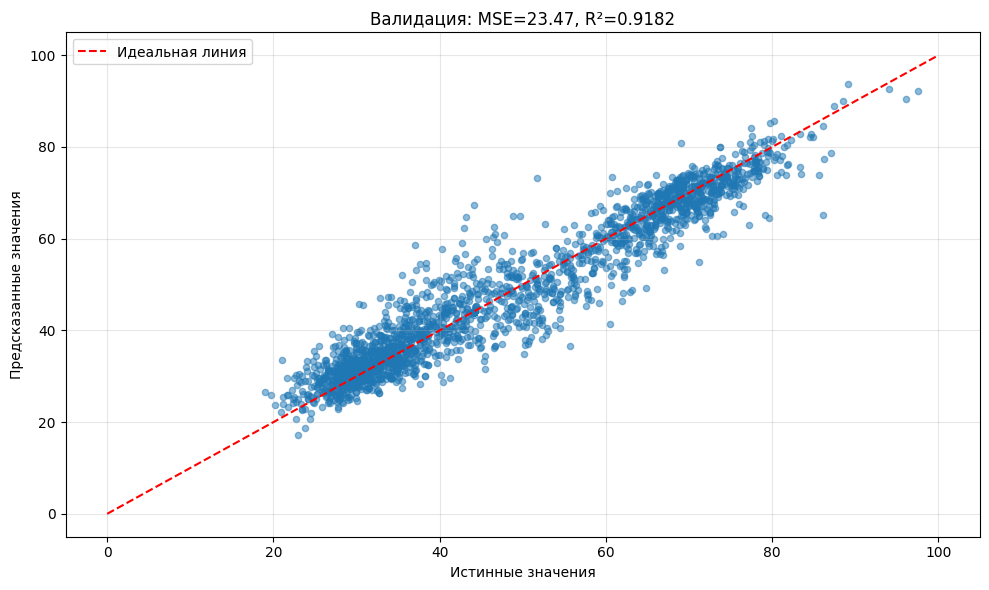

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(y_val, pred_val, alpha=0.5, s=20)
plt.plot([0, 100], [0, 100], 'r--', label='Идеальная линия')
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Валидация: MSE={mse_val:.2f}, R²={r2_val:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
pred_test_scaled = model.predict(X_test_scaled)
pred_test = scaler_y.inverse_transform(pred_test_scaled.reshape(-1, 1)).ravel()
pred_test = np.clip(pred_test, 0, 100)

In [45]:
submission = pd.DataFrame({'ID': test_ids, 'RiskScore': pred_test})
submission.to_csv('submission.csv', index=False)